In [17]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from mma.metrics.mma import get_mma
import matplotlib.colors as mcolors

In [18]:
# Load Example
img = Image.open('../mma/datasets/demo_example/img.png')
ann = np.load('../mma/datasets/demo_example/ann.npy')
pred = np.load('../mma/datasets/demo_example/output.npy')

GROUND TRUTH


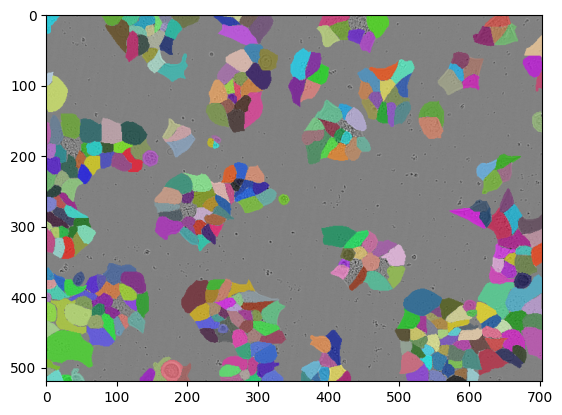

PREDICTED


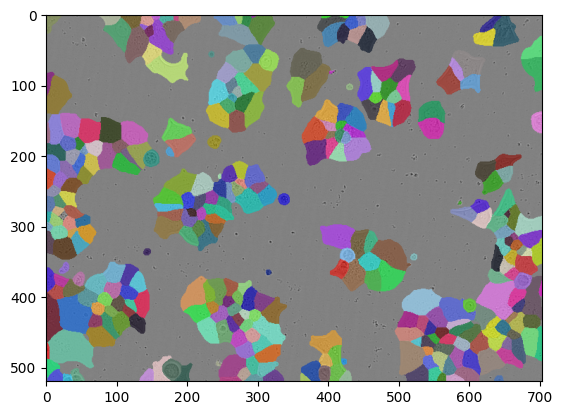

In [24]:
# Visualize Example
def convert_label_to_rainbow(label):
    label_rainbow = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for cell in np.unique(label):
        if cell == 0:
            continue #background
        label_rainbow[label == cell] = np.clip(np.random.rand(3) * 255, a_min=10, a_max=255)

    return label_rainbow


print('GROUND TRUTH')
ann_rgb = convert_label_to_rainbow(ann)
ann_rgb[ann == 0] = cv2.cvtColor(np.array(img), cv2.COLOR_GRAY2RGB)[ann == 0]

plt.imshow(img, cmap='gray')
plt.imshow(ann_rgb, alpha=0.7)
plt.show()

print('PREDICTED')
pred_rgb = convert_label_to_rainbow(pred)
pred_rgb[pred == 0] = cv2.cvtColor(np.array(img), cv2.COLOR_GRAY2RGB)[pred == 0]

plt.imshow(img, cmap='gray')
plt.imshow(pred_rgb, alpha=0.7)
plt.show()


MMA: 0.6961170130441191


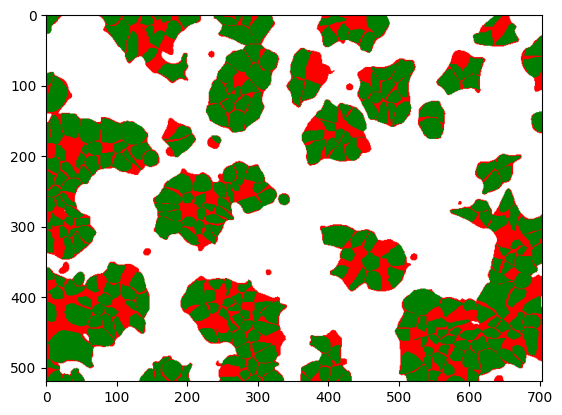

In [22]:
#Compute MMA
mma, accuracy_plot = get_mma(pred, ann, greedy=False, return_accuracy_plot=True)

print(f'MMA: {mma}')

colors = ['white', 'red', 'green']
cmap = mcolors.ListedColormap(colors)
plt.imshow(accuracy_plot, cmap=cmap)
plt.show()